# Crypt Composition Figures

This notebook builds publication-style summaries from the saved graph crypt segmentations. The two day 4.5 batches are intentionally pooled under one `day 4.5` label; `SAMPLE_ORDER` keeps each plotted group unique.


In [1]:
# If you edit paths or grouping, re-run this cell and everything below.
import os
import warnings
import glob
from functools import lru_cache

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get

from organograph.crypts.analysis_markers import (
    bin_marker_positivity,
    get_marker_counts_per_patch,
    assign_coexpression_category,
)
from organograph.crypts.filters import filter_crypts_by_markers
from organograph.io_utils.segmentation_io import (
    load_graph_crypt_segmentation,
    load_mesh_crypt_segmentation,
)
from organograph.mesh.OrganoidMesh import OrganoidMesh
from organograph.mesh.hks import compute_hks
from organograph.plotting.colors import resolve_category_colors
from organograph.skeleton.build import (
    _low_pass_smoothed_mesh_for_detection,
    _select_hks_tips_from_axis,
)


## Configuration

Edit dataset paths, marker filters, and plotting targets here. `DATA_SPECS` may contain multiple datasets with the same display label; downstream tables group by that label.


In [2]:
# -----------------------
# CONFIG
# -----------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_ROOT    = os.path.join(PROJECT_ROOT, "..", "NicoleData")

# For each dataset you can now specify:
#   - dataset: dataset folder
#   - seg_subdir: segmentation folder inside that dataset
#   - graph_subdir: graph folder inside that dataset
#   - timepoints: list of timepoints to include (or None for auto-discover)
#   - label: label shown on plots
DATA_SPECS = [
    # {
    #     "dataset": "20250929",
    #     "seg_subdir": "crypt_segmentations_graph_3p5selected",
    #     "graph_subdir": "graphs_preprocessed_exclusive",
    #     "timepoints": ["day3p5"],
    #     "label": "day 3.5 (good)",
    # },
    {
        "dataset": "20250929",
        "seg_subdir": "crypt_segmentations_graph_exclusive",
        "graph_subdir": "graphs_preprocessed_exclusive",
        "timepoints": ["day3p5"],
        "label": "day 3.5",
    },
    {
        "dataset": "20250929",
        "seg_subdir": "crypt_segmentations_graph_exclusive",
        "graph_subdir": "graphs_preprocessed_exclusive",
        "timepoints": ["day4p5"],
        "label": "day 4.5",
    },
    {
        "dataset": "20251201",
        "seg_subdir": "crypt_segmentations_graph_exclusive",
        "graph_subdir": "graphs_preprocessed_exclusive",
        "timepoints": ["day4p5"],
        "label": "day 4.5",
    },
]

# Optional marker names used only for coexpression_cat if present in a given graph.
COEX_MARKERS = {
    "LGR5": "LGR5",
    "Sero": "Serotonin",
    "Lyso": "Lysozyme",
}

# Optional crypt filter settings.
# This version resolves marker indices separately inside each graph.
USE_CRYPT_FILTER = True

CRYPT_FILTER_KW = dict(
    pos_marker_names=['LGR5', 'Chroma', 'Agr2', 'Serotonin', 'Lysozyme'],      # e.g. ["LGR5"]
    neg_marker_names=["AldoB"],
    pos_min=1,
    neg_min=2,
    roi_frac=0.75,
    require_all_pos=False,
)

MIN_POSITIVE = 1
POS_THRESHOLD = 1


TARGET_MARKERS = [
    "LGR5",
    "Serotonin",
    "Lysozyme",
    "Exocrine (Agr2+Lysozyme)",
    "Endocrine (Serotonin+ChromA)",
]
DERIVED_MARKER_GROUPS = {
    "Exocrine (Agr2+Lysozyme)": ["Agr2", "Lysozyme"],
    "Endocrine (Serotonin+ChromA)": ["Serotonin", "ChromA"],
}
NORMALIZED_DISTANCE_BIN_EDGES = np.linspace(0.0, 1.2, 10)
GRAPH_HOP_MAX = 10


def ordered_unique(values):
    seen = set()
    out = []
    for value in values:
        if value not in seen:
            seen.add(value)
            out.append(value)
    return out


SAMPLE_ORDER = ordered_unique(d["label"] for d in DATA_SPECS)


## Load Crypt-Level Table

The inspection table is one row per retained crypt. It loads each graph segmentation, resolves its graph, applies the optional marker-aware crypt filter, and records marker counts plus saved morphology descriptors.


In [3]:
from organograph.io_utils.cells_table import harmonize_markers

def discover_timepoints(seg_dir):
    if not os.path.isdir(seg_dir):
        return []
    tps = []
    for name in sorted(os.listdir(seg_dir)):
        p = os.path.join(seg_dir, name)
        if os.path.isdir(p) and glob.glob(os.path.join(p, "*.npz")):
            tps.append(name)
    return tps


def _seg_get(seg, *keys, default=None):
    for k in keys:
        if k in seg:
            return seg[k]
    return default


def _safe_array(x):
    if x is None:
        return None
    return np.asarray(x)


def _as_list_of_lists(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [list(xx) for xx in x]
    if isinstance(x, np.ndarray) and x.dtype == object:
        return [list(xx) for xx in x.tolist()]
    return [list(xx) for xx in x]


def _infer_marker_names(G):
    """
    Read marker names from the graph itself.
    """
    for k in ["marker_names", "markers", "marker_cols"]:
        v = G.graph.get(k, None)
        if v is not None:
            return list(v)

    markers_bin = graph_get(G, "markers_bin")
    n_markers = markers_bin.shape[1]
    return [f"marker_{i}" for i in range(n_markers)]


def _infer_label_uid(G, fallback=None):
    return G.graph.get("label_uid", None) or fallback


@lru_cache(maxsize=None)
def load_graph_cached(graph_path):
    return load_cell_graph(graph_path)


def build_dataset_paths(data_spec, data_root):
    dataset = data_spec["dataset"]

    seg_subdir = data_spec.get("seg_subdir", "crypt_segmentations_graph")
    graph_subdir = data_spec.get("graph_subdir", "graphs_preprocessed")

    seg_dir = os.path.join(data_root, dataset, seg_subdir)
    graphs_dir = os.path.join(data_root, dataset, graph_subdir)

    return seg_dir, graphs_dir


def resolve_graph_path(seg, graphs_dir):
    """
    Prefer the graph path stored in the segmentation if it exists.
    Otherwise try to rebuild it relative to the dataset-specific graphs_dir.
    """
    graph_path = seg.get("graph_path", None)

    if graph_path is not None and os.path.exists(graph_path):
        return graph_path

    if graph_path is None:
        return None

    # fallback: use basename inside graphs_dir
    base = os.path.basename(graph_path)
    candidate = os.path.join(graphs_dir, base)
    if os.path.exists(candidate):
        return candidate

    return graph_path


def resolve_mesh_path(seg, dataset_root=None):
    mesh_path = seg.get("mesh_path", None)
    if mesh_path is None:
        return None
    return mesh_path


def iter_selected_seg_paths(data_specs, data_root, verbose=True):
    """
    Iterate through all requested segmentation files.
    Yields dicts with:
      dataset, timepoint, label, seg_path, seg_dir, graphs_dir
    """
    for ds in data_specs:
        seg_dir, graphs_dir = build_dataset_paths(ds, data_root)

        tps = ds.get("timepoints", None)
        if tps is None:
            tps = discover_timepoints(seg_dir)

        for tp in tps:
            tp_dir = os.path.join(seg_dir, tp)
            seg_paths = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))

            if verbose and len(seg_paths) == 0:
                print(f"[warn] no segmentation files found in: {tp_dir}")

            for seg_path in seg_paths:
                yield {
                    "dataset": ds["dataset"],
                    "timepoint": tp,
                    "label": ds.get("label", f'{ds["dataset"]}:{tp}'),
                    "seg_path": seg_path,
                    "seg_dir": seg_dir,
                    "graphs_dir": graphs_dir,
                }
                

def infer_common_markers(data_specs, data_root, verbose=True):
    """
    Intersect marker names across all selected graphs.
    Returns common markers in the order they first appear.
    """
    marker_sets = []
    ordered_first = None

    for item in iter_selected_seg_paths(data_specs, data_root, verbose=verbose):
        seg_path = item["seg_path"]
        graphs_dir = item["graphs_dir"]

        try:
            seg = load_graph_crypt_segmentation(seg_path)
            graph_path = resolve_graph_path(seg, graphs_dir=graphs_dir)
            G = load_graph_cached(graph_path)
            marker_names = _infer_marker_names(G)
        except Exception as e:
            if verbose:
                print(f"[skip common-marker scan] {seg_path}: {e}")
            continue

        marker_set = set(marker_names)
        marker_sets.append(marker_set)

        if ordered_first is None:
            ordered_first = list(marker_names)

    if len(marker_sets) == 0:
        return []

    common = set.intersection(*marker_sets)
    if ordered_first is None:
        return sorted(common)

    return [m for m in ordered_first if m in common]


def make_graph_aware_crypt_filter(
    pos_marker_names=None,
    neg_marker_names=None,
    pos_min=2,
    neg_min=2,
    roi_frac=0.65,
    require_all_pos=True,
):
    pos_marker_names = [] if pos_marker_names is None else list(pos_marker_names)
    neg_marker_names = [] if neg_marker_names is None else list(neg_marker_names)

    def _crypt_filter(G, crypts_graph, seg, marker_names):
        name_to_idx = {m: i for i, m in enumerate(marker_names)}

        pos_markers = [name_to_idx[m] for m in pos_marker_names if m in name_to_idx]
        neg_markers = [name_to_idx[m] for m in neg_marker_names if m in name_to_idx]

        # If a requested positive marker is absent, require nothing from it.
        # If a requested negative marker is absent, also ignore it.
        return filter_crypts_by_markers(
            G,
            crypts_graph,
            pos_markers=pos_markers,
            neg_markers=neg_markers,
            pos_min=pos_min,
            neg_min=neg_min,
            roi_frac=roi_frac,
            dist_bottom=seg["d_crypts_graph"],
            require_all_pos=require_all_pos,
        )

    return _crypt_filter


def lighten_color(rgb_or_hex, amount=0.65):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))


def load_seg_cached(seg_path):
    return load_graph_crypt_segmentation(seg_path)


def get_roi_cells_for_crypt(crypt_cells, dist_bottom, crypt_number=None, roi_frac=None):
    """
    Restrict crypt cells to those with dist_bottom <= roi_frac.

    Supports:
      - dist_bottom shape (N_cells,)          : one global per-cell array
      - dist_bottom shape (K_crypts, N_cells) : one row per crypt

    Parameters
    ----------
    crypt_cells : list[int]
        Cell ids belonging to this crypt.
    dist_bottom : array-like
        Either shape (N_cells,) or (K_crypts, N_cells).
    crypt_number : int or None
        Required when dist_bottom has shape (K_crypts, N_cells).
        Should be the original crypt index in the segmentation.
    roi_frac : float or None
        If None, keep all crypt cells.
        Otherwise keep only cells with dist_bottom <= roi_frac.

    Returns
    -------
    roi_cells : np.ndarray of int
    """
    idx = np.asarray(list(crypt_cells), dtype=np.int64)

    if roi_frac is None:
        return idx

    db = np.asarray(dist_bottom, dtype=float)

    if db.ndim == 1:
        db_row = db

    elif db.ndim == 2:
        if crypt_number is None:
            raise ValueError(
                "crypt_number is required when dist_bottom has shape (K_crypts, N_cells)."
            )
        if crypt_number < 0 or crypt_number >= db.shape[0]:
            raise ValueError(
                f"crypt_number={crypt_number} out of range for dist_bottom with shape {db.shape}."
            )
        db_row = db[int(crypt_number)]

    else:
        raise ValueError(
            "dist_bottom must have shape (N_cells,) or (K_crypts, N_cells)."
        )

    if np.any(idx < 0) or np.any(idx >= len(db_row)):
        raise ValueError("crypt_cells contains indices out of range for dist_bottom.")

    dvals = db_row[idx]
    keep = np.isfinite(dvals) & (dvals <= float(roi_frac))
    return idx[keep]


def compute_crypt_shape_metrics(seg, crypt_idx, fullness_power=1.0):
    """
    Compute scalar shape metrics for one crypt from segmentation data.

    Metrics
    -------
    crypt_length : float
        L

    crypt_cmax : float
        max circumference inside crypt (d_discretized <= 1)

    crypt_slenderness : float
        L / C_max

    crypt_fullness : float
        Weighted mean normalized position of circumference:
            mu = (∫ d * C(d)^p dd) / (∫ C(d)^p dd)

    crypt_circ_pos_var : float
        Weighted variance of circumference position:
            var = (∫ (d-mu)^2 * C(d)^p dd) / (∫ C(d)^p dd)

    crypt_circ_pos_spread : float
        sqrt(var)

    crypt_circ_pos_spread_norm : float
        2 * sqrt(var), roughly scaled to [0, 1]
    """
    L_crypts = _safe_array(_seg_get(seg, "L_crypts", default=None))
    circumference_crypts = _safe_array(_seg_get(seg, "circumference_crypts", default=None))
    d_discretized = _safe_array(_seg_get(seg, "d_discretized", default=None))

    out = {
        "crypt_length": np.nan,
        "crypt_cmax": np.nan,
        "crypt_slenderness": np.nan,
        "crypt_fullness": np.nan,
        "crypt_circ_pos_var": np.nan,
        "crypt_circ_pos_spread": np.nan,
        "crypt_circ_pos_spread_norm": np.nan,
    }

    if L_crypts is None or circumference_crypts is None or d_discretized is None:
        return out

    if crypt_idx < 0 or crypt_idx >= len(L_crypts):
        return out

    try:
        L = float(L_crypts[crypt_idx])
        C = np.asarray(circumference_crypts[crypt_idx], dtype=float)
        d = np.asarray(d_discretized, dtype=float)
    except Exception:
        return out

    if C.ndim != 1 or d.ndim != 1 or len(C) != len(d):
        return out

    keep = np.isfinite(d) & np.isfinite(C) & (d <= 1.0)
    if not np.any(keep):
        return out

    d_roi = d[keep]
    C_roi = C[keep]

    order = np.argsort(d_roi)
    d_roi = d_roi[order]
    C_roi = C_roi[order]

    C_max = float(np.nanmax(C_roi)) if len(C_roi) > 0 else np.nan
    slenderness = float(L / C_max) if np.isfinite(L) and C_max > 0 else np.nan

    p = float(fullness_power)
    if p <= 0:
        raise ValueError("fullness_power must be > 0")

    W = C_roi ** p
    denom = np.trapezoid(W, d_roi)

    if denom > 0:
        mu = float(np.trapezoid(d_roi * W, d_roi) / denom)
        var = float(np.trapezoid(((d_roi - mu) ** 2) * W, d_roi) / denom)
        var = max(var, 0.0)
        spread = float(np.sqrt(var))
        spread_norm = float(2.0 * spread)
    else:
        mu = np.nan
        var = np.nan
        spread = np.nan
        spread_norm = np.nan

    return {
        "crypt_length": L,
        "crypt_cmax": C_max,
        "crypt_slenderness": slenderness,
        "crypt_fullness": mu,
        "crypt_circ_pos_var": var,
        "crypt_circ_pos_spread": spread,
        "crypt_circ_pos_spread_norm": spread_norm,
    }


### Inspect Stored Segmentation Variables

This quick check loads one graph segmentation from each `DATA_SPECS` entry and prints every stored variable with shape and dtype. Use it to confirm whether fields such as `curvature_gauss_graph` are available for each dataset/timepoint.


In [4]:
def _candidate_data_roots(preferred_data_root):
    roots = [preferred_data_root]
    cwd = os.getcwd()
    for candidate in [
        os.path.join(cwd, "..", "NicoleData"),
        os.path.join(cwd, "NicoleData"),
        os.path.join(cwd, "..", "..", "NicoleData"),
    ]:
        candidate = os.path.abspath(candidate)
        if candidate not in roots:
            roots.append(candidate)
    return roots


def _seg_dir_has_npz(seg_dir, timepoints):
    if timepoints is None:
        return bool(glob.glob(os.path.join(seg_dir, "*", "*.npz")))
    return any(glob.glob(os.path.join(seg_dir, tp, "*.npz")) for tp in timepoints)


def _resolve_existing_dataset_paths(data_spec, data_root):
    timepoints = data_spec.get("timepoints", None)
    for root in _candidate_data_roots(data_root):
        seg_dir, graphs_dir = build_dataset_paths(data_spec, root)
        if _seg_dir_has_npz(seg_dir, timepoints):
            return root, seg_dir, graphs_dir
    seg_dir, graphs_dir = build_dataset_paths(data_spec, data_root)
    return data_root, seg_dir, graphs_dir


def print_one_segmentation_variables_per_dataset(data_specs, data_root):
    for spec in data_specs:
        label = spec.get("label", spec.get("dataset", "dataset"))
        dataset = spec["dataset"]
        used_root, seg_dir, _graphs_dir = _resolve_existing_dataset_paths(spec, data_root)
        timepoints = spec.get("timepoints", None) or discover_timepoints(seg_dir)

        print("=" * 88)
        print(f"dataset={dataset} | label={label}")
        print(f"data_root={used_root}")
        print(f"seg_dir={seg_dir}")

        found = False
        for tp in timepoints:
            seg_paths = sorted(glob.glob(os.path.join(seg_dir, tp, "*.npz")))
            if not seg_paths:
                print(f"  {tp}: no .npz files found")
                continue

            seg_path = seg_paths[0]
            found = True
            print(f"  timepoint={tp}")
            print(f"  example={seg_path}")

            z = np.load(seg_path, allow_pickle=True)
            for key in z.files:
                value = z[key]
                shape = getattr(value, "shape", None)
                dtype = getattr(value, "dtype", type(value).__name__)
                extra = ""
                if np.asarray(value).shape == ():
                    try:
                        extra = f" value={value.item()}"
                    except Exception:
                        extra = ""
                print(f"    {key:<28} shape={str(shape):<16} dtype={dtype}{extra}")
            break

        if not found:
            print("  no segmentation files found for requested timepoints")


print_one_segmentation_variables_per_dataset(DATA_SPECS, DATA_ROOT)


dataset=20250929 | label=day 3.5
data_root=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData
seg_dir=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/crypt_segmentations_graph_exclusive
  timepoint=day3p5
  example=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/crypt_segmentations_graph_exclusive/day3p5/day3p5_A01_1.npz
    label_uid                    shape=()               dtype=<U12 value=day3p5_A01_1
    timepoint                    shape=()               dtype=<U6 value=day3p5
    mesh_seg_path                shape=()               dtype=<U137 value=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/crypt_segmentations_mesh_day3p5_prct4/day3p5/day3p5_A01_1.npz
    mesh_path                    shape=()               dtype=<U169 value=/home/fmoller/Projects/LearningOrganoids/NicoleData/20250929/fractal_output/day3p5/r0.zarr/A/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annota

In [5]:
def build_inspection_table_multi(
    data_specs,
    data_root,
    verbose=True,
    min_positive=1,
    pos_threshold=1,
    coex_markers=None,
    crypt_filter=None,
):
    rows_out = []

    coex_markers = {} if coex_markers is None else dict(coex_markers)

    for item in iter_selected_seg_paths(data_specs, data_root, verbose=verbose):
        dataset = item["dataset"]
        tp = item["timepoint"]
        label = item["label"]
        seg_path = item["seg_path"]
        graphs_dir = item["graphs_dir"]

        # load segmentation
        try:
            seg = load_graph_crypt_segmentation(seg_path)
        except Exception as e:
            if verbose:
                print(f"[skip] could not load segmentation {seg_path}: {e}")
            continue

        # resolve graph path using dataset-specific graphs_dir
        graph_path = resolve_graph_path(seg, graphs_dir=graphs_dir)

        # load graph
        try:
            G = load_graph_cached(graph_path)
        except Exception as e:
            if verbose:
                print(f"[skip] could not load graph {graph_path}: {e}")
            continue

        marker_names = _infer_marker_names(G)
        name_to_idx = {m: i for i, m in enumerate(marker_names)}

        crypts_graph = _as_list_of_lists(
            _seg_get(seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[])
        )
        constrictions = _safe_array(_seg_get(seg, "crypt_constrictions", default=None))
        elongations = _safe_array(_seg_get(seg, "crypt_elongations", "crypt_elongationss", default=None))
        graph_patch_sizes = _safe_array(_seg_get(seg, "graph_patch_sizes", default=None))

        label_uid = _seg_get(seg, "label_uid", default=None)
        label_uid = _infer_label_uid(G, fallback=label_uid)

        n_crypts = len(crypts_graph)

        # run filter once
        if crypt_filter is None:
            keep_idx = np.arange(n_crypts, dtype=np.int64)
        else:
            keep = crypt_filter(G, crypts_graph, seg, marker_names)

            if isinstance(keep, np.ndarray) and keep.dtype == bool:
                if len(keep) != n_crypts:
                    raise ValueError(
                        f"crypt_filter returned boolean mask of length {len(keep)}, "
                        f"expected {n_crypts}"
                    )
                keep_idx = np.flatnonzero(keep)
            else:
                keep_idx = np.asarray(keep, dtype=np.int64)

        if keep_idx.ndim != 1:
            raise ValueError("keep_idx must be a 1D array of crypt indices")
        if len(keep_idx) > 0:
            if keep_idx.min() < 0 or keep_idx.max() >= n_crypts:
                raise ValueError("crypt_filter returned out-of-range crypt indices")

        crypts_graph_f = [crypts_graph[j] for j in keep_idx]
        constrictions_f = constrictions[keep_idx] if constrictions is not None else None
        elongations_f = elongations[keep_idx] if elongations is not None else None
        graph_patch_sizes_f = graph_patch_sizes[keep_idx] if graph_patch_sizes is not None else None
        orig_crypt_numbers_f = keep_idx

        # coexpression indices if present in this graph
        i_LGR5 = name_to_idx.get(coex_markers.get("LGR5", ""), None)
        i_Sero = name_to_idx.get(coex_markers.get("Sero", ""), None)
        i_Lyso = name_to_idx.get(coex_markers.get("Lyso", ""), None)

        for local_idx, crypt_cells in enumerate(crypts_graph_f):
            crypt_cells = list(crypt_cells)
            if len(crypt_cells) == 0:
                continue

            orig_j = int(orig_crypt_numbers_f[local_idx])

            shape_metrics = compute_crypt_shape_metrics(seg, orig_j)

            num_pos_cells, num_cells = get_marker_counts_per_patch(G, crypt_cells)
            num_pos_cells = np.asarray(num_pos_cells, dtype=np.int64)

            if num_pos_cells.shape[0] != len(marker_names):
                raise ValueError(
                    f"Marker count mismatch for {seg_path}: "
                    f"counts have length {num_pos_cells.shape[0]}, "
                    f"marker_names has length {len(marker_names)}"
                )

            has_marker = (num_pos_cells >= min_positive).astype(np.int64)

            if None not in (i_LGR5, i_Sero, i_Lyso):
                coexpression_cat = assign_coexpression_category(
                    G,
                    crypt_cells,
                    i_LGR5,
                    i_Sero,
                    i_Lyso,
                    pos_threshold=pos_threshold,
                )
            else:
                coexpression_cat = np.nan

            constr = (
                float(constrictions_f[local_idx])
                if constrictions_f is not None and local_idx < len(constrictions_f)
                else np.nan
            )

            row = {
                "dataset": dataset,
                "timepoint": tp,
                "sample_label": label,
                "label_uid": label_uid,
                "crypt_number": orig_j,
                "crypt_number_filtered": local_idx,
                "graph_path": graph_path,
                "mesh_path": seg.get("mesh_path", None),
                "seg_path": seg_path if os.path.exists(seg_path) else None,
                "has_seg": bool(os.path.exists(seg_path)),
                "num_cells": int(num_cells),
                "constriction": constr,
                "elongation": (
                    float(elongations_f[local_idx])
                    if elongations_f is not None and local_idx < len(elongations_f)
                    else np.nan
                ),
                "graph_patch_size": (
                    int(graph_patch_sizes_f[local_idx])
                    if graph_patch_sizes_f is not None and local_idx < len(graph_patch_sizes_f)
                    else int(num_cells)
                ),
                "coexpression_cat": coexpression_cat,
                "is_budded": (constr > 0) if not np.isnan(constr) else np.nan,
                "crypt_cells": crypt_cells,
                "graph_marker_names": tuple(marker_names),
                "crypt_length": shape_metrics["crypt_length"],
                "crypt_cmax": shape_metrics["crypt_cmax"],
                "crypt_slenderness": shape_metrics["crypt_slenderness"],
                "crypt_fullness": shape_metrics["crypt_fullness"],
                "crypt_circ_pos_var": shape_metrics["crypt_circ_pos_var"],
                "crypt_circ_pos_spread": shape_metrics["crypt_circ_pos_spread"],
                "crypt_circ_pos_spread_norm": shape_metrics["crypt_circ_pos_spread_norm"],
            }

            for k, mk in enumerate(marker_names):
                row[f"{mk}_n_pos"] = int(num_pos_cells[k])
                row[f"{mk}_frac_pos"] = float(num_pos_cells[k] / num_cells) if num_cells > 0 else np.nan
                row[f"{mk}_has"] = int(has_marker[k])

            rows_out.append(row)

    df = pd.DataFrame(rows_out)

    if len(df) == 0:
        return df

    has_cols = [c for c in df.columns if c.endswith("_has")]
    if len(has_cols) > 0:
        df["n_markers_present"] = df[has_cols].fillna(0).sum(axis=1)

    return df


In [6]:
crypt_filter = None
if USE_CRYPT_FILTER:
    crypt_filter = make_graph_aware_crypt_filter(**CRYPT_FILTER_KW)


common_markers = infer_common_markers(DATA_SPECS, DATA_ROOT, verbose=True)
print("COMMON MARKERS =", common_markers)

inspection_df = build_inspection_table_multi(
    data_specs=DATA_SPECS,
    data_root=DATA_ROOT,
    verbose=True,
    min_positive=MIN_POSITIVE,
    pos_threshold=POS_THRESHOLD,
    coex_markers=COEX_MARKERS,
    crypt_filter=crypt_filter,
)

print("inspection_df shape:", inspection_df.shape)
inspection_df.head()

print("sample groups:", SAMPLE_ORDER)


COMMON MARKERS = ['LGR5', 'Chroma', 'AldoB', 'Agr2', 'Serotonin', 'Lysozyme', 'TA']
inspection_df shape: (583, 53)
sample groups: ['day 3.5', 'day 4.5']


## Pooled Marker Composition

These bars pool all cells in retained crypts within each display group and show the marker composition shared by all selected datasets.


composition_df shape: (2, 12)


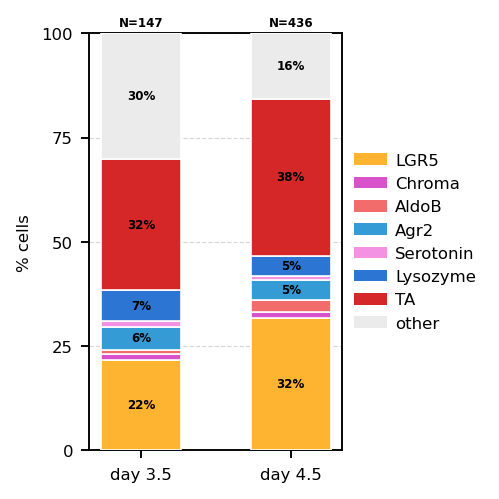

,sample_label,n_crypts,total_cells,roi_frac,LGR5_pct_cells,Chroma_pct_cells,AldoB_pct_cells,Agr2_pct_cells,Serotonin_pct_cells,Lysozyme_pct_cells,TA_pct_cells,other_pct_cells
0,day 3.5,147,5249,None,21.813679,1.257382,1.047819,5.601067,1.409792,7.296628,31.586969,29.986664
1,day 4.5,436,37245,None,31.776077,1.514297,2.792321,4.797959,1.044435,4.806014,37.556719,15.712176


In [7]:
def summarize_markers_per_sample(inspection_df):
    rows = []
    for sample_label, g in inspection_df.groupby("sample_label", sort=False):
        marker_sets = g["graph_marker_names"].dropna().tolist()
        unique_markers = sorted(set().union(*[set(ms) for ms in marker_sets])) if len(marker_sets) else []
        rows.append({
            "sample_label": sample_label,
            "n_crypts": len(g),
            "markers_found": unique_markers,
        })
    return pd.DataFrame(rows)

marker_summary_df = summarize_markers_per_sample(inspection_df)
marker_summary_df

def build_pooled_common_marker_composition_table(
    inspection_df,
    common_markers,
    sample_col="sample_label",
    roi_frac=None,
):
    """
    Build one row per sample_label.

    For each common marker:
        pct(marker) = 100 * (total positive ROI cells for marker) / (total ROI cells)

    Then:
        pct(other) = 100 - sum_i pct(common_marker_i)

    Parameters
    ----------
    inspection_df : pd.DataFrame
        Must contain at least:
          - graph_path
          - seg_path
          - crypt_cells
          - crypt_number
          - sample_label

    common_markers : list[str]
        Markers that should be shown explicitly.

    roi_frac : float or None
        If not None, only count cells with seg["d_crypts_graph"] <= roi_frac.
        Should be between 0 and 1.

    Notes
    -----
    - Cells may contribute to multiple common markers.
    - Therefore 'other' is defined by subtraction exactly as requested.
    - AldoB is included in 'other' automatically unless it is in common_markers.
    """
    if roi_frac is not None:
        roi_frac = float(roi_frac)
        if not (0.0 <= roi_frac <= 1.0):
            raise ValueError("roi_frac must be in [0, 1] or None.")

    rows = []

    for sample_label, g in inspection_df.groupby(sample_col, sort=False):
        total_roi_cells = 0
        marker_pos_counts = {mk: 0 for mk in common_markers}
        n_crypts_used = 0

        for _, r in g.iterrows():
            graph_path = r["graph_path"]
            seg_path = r["seg_path"]
            crypt_cells = r["crypt_cells"]
            crypt_number = int(r["crypt_number"])

            if pd.isna(seg_path) or seg_path is None:
                continue
            if graph_path is None:
                continue

            G = load_graph_cached(graph_path)
            seg = load_seg_cached(seg_path)

            if "d_crypts_graph" not in seg:
                if roi_frac is not None:
                    raise KeyError(
                        f"seg['d_crypts_graph'] missing for seg_path={seg_path}, "
                        "but roi_frac was requested."
                    )
                dist_bottom = None
            else:
                dist_bottom = np.asarray(seg["d_crypts_graph"], dtype=float)

            marker_names = _infer_marker_names(G)
            name_to_idx = {m: i for i, m in enumerate(marker_names)}

            if roi_frac is None:
                roi_cells = np.asarray(list(crypt_cells), dtype=np.int64)
            else:
                roi_cells = get_roi_cells_for_crypt(
                    crypt_cells=crypt_cells,
                    dist_bottom=dist_bottom,
                    crypt_number=crypt_number,
                    roi_frac=roi_frac,
                )

            if roi_cells.size == 0:
                continue

            n_crypts_used += 1
            total_roi_cells += int(roi_cells.size)

            markers_bin = np.asarray(graph_get(G, "markers_bin"))
            X = np.asarray(markers_bin[roi_cells], dtype=float)

            for mk in common_markers:
                if mk not in name_to_idx:
                    continue
                k = name_to_idx[mk]
                marker_pos_counts[mk] += int(np.sum(X[:, k] > 0))

        row = {
            "sample_label": sample_label,
            "n_crypts": int(n_crypts_used),
            "total_cells": int(total_roi_cells),
            "roi_frac": roi_frac,
        }

        if total_roi_cells <= 0:
            for mk in common_markers:
                row[f"{mk}_pct_cells"] = np.nan
            row["other_pct_cells"] = np.nan
            rows.append(row)
            continue

        sum_common = 0.0
        for mk in common_markers:
            pct = 100.0 * float(marker_pos_counts[mk]) / float(total_roi_cells)
            row[f"{mk}_pct_cells"] = pct
            sum_common += pct

        row["other_pct_cells"] = 100.0 - sum_common
        rows.append(row)

    return pd.DataFrame(rows)

def plot_pooled_common_marker_composition(
    pooled_df,
    dataset_order=None,
    common_markers=None,
    other_label="other",
    color_scheme=None,
    figsize=None,
    dpi=170,
    percent_text_threshold=7.0,
    title="",
):
    """
    One stacked bar per dataset/timepoint label.

    For each bar:
      - each common marker is plotted with its percentage of positive cells
      - 'other' = 100 - sum(common marker percentages)

    Styling is matched to the compact proportions of
    plot_lgr5_composition_from_inspection_table():
      - compact figure
      - narrow bars
      - smaller fonts
      - legend on the right, outside axes, single column
    """
    df = pooled_df.copy()

    if len(df) == 0:
        raise ValueError("pooled_df is empty")

    if common_markers is None:
        common_markers = [
            c[:-10] for c in df.columns
            if c.endswith("_pct_cells") and c != "other_pct_cells"
        ]

    categories = list(common_markers) + [other_label]

    if dataset_order is None:
        dataset_order = list(pd.unique(df["sample_label"]))

    df = df.set_index("sample_label").reindex(dataset_order)

    # --- compute compact figure width automatically ---
    n = len(dataset_order)

    if figsize is None:
        # these numbers are tuned to your current style
        base_w = 0.8          # minimal margin + legend room
        per_bar_w = 0.85      # horizontal space per bar
        fig_w = base_w + per_bar_w * n
        fig_h = 4.2 * 0.80

        figsize = (fig_w, fig_h)

    x = np.arange(len(dataset_order), dtype=float) * 0.75
    w = 0.40

    color_map = resolve_category_colors(
        categories=categories,
        color_scheme=color_scheme,
        other_label=other_label,
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # leave room on the right for legend
    fig.subplots_adjust(right=0.72, top=0.84)

    bottom = np.zeros(len(dataset_order), dtype=float)

    for cat in categories:
        col = f"{cat}_pct_cells" if cat != other_label else "other_pct_cells"
        vals = df[col].to_numpy(dtype=float)

        bars = ax.bar(
            x,
            vals,
            width=w,
            bottom=bottom,
            color=color_map[cat],
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
            label=cat,
        )

        for rect, val, btm in zip(bars, vals, bottom):
            if not np.isfinite(val) or val < percent_text_threshold:
                continue

            ax.text(
                rect.get_x() + rect.get_width() / 2,
                btm + val / 2,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=5,
                fontweight="bold",
                color="black",
                clip_on=True,
                zorder=4,
            )

        bottom = bottom + np.nan_to_num(vals, nan=0.0)

    # N labels above bars
    trans = ax.get_xaxis_transform()
    Ns = df["n_crypts"].fillna(0).to_numpy(dtype=int)
    for j in range(len(dataset_order)):
        ax.text(
            x[j], 1.01, f"N={Ns[j]}",
            transform=trans,
            ha="center",
            va="bottom",
            fontsize=5,
            fontweight="bold",
            clip_on=False,
        )

    # axis styling
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, fontsize=7)
    ax.set_ylabel("% cells", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)

    roi_vals = df["roi_frac"].dropna().unique() if "roi_frac" in df.columns else []
    if len(roi_vals) == 1:
        ax.set_title(f"{title} (ROI ≤ {roi_vals[0]:.2f})", fontsize=8)
    else:
        ax.set_title(title, fontsize=8)

    # legend on right, outside, single column
    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_map[cat], edgecolor="none")
        for cat in categories
    ]
    labels = categories

    ax.legend(
        handles,
        labels,
        frameon=False,
        ncol=1,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=7,
        borderaxespad=0.0,
        handletextpad=0.5,
        columnspacing=0.8,
    )

    plt.show()

    return df.reset_index()

pooled_composition_df = build_pooled_common_marker_composition_table(
    inspection_df=inspection_df,
    common_markers=common_markers,
    sample_col="sample_label",
    roi_frac=None,
)


print("composition_df shape:", pooled_composition_df.shape)
pooled_composition_df.head()

plot_df = plot_pooled_common_marker_composition(
    pooled_df=pooled_composition_df,
    dataset_order=SAMPLE_ORDER,
    common_markers=common_markers,
    percent_text_threshold=3.0,
)

plot_df


## LGR5 and Coexpression Composition

These summaries operate at crypt level: first by LGR5 status, then by the LGR5/Serotonin/Lysozyme coexpression categories.


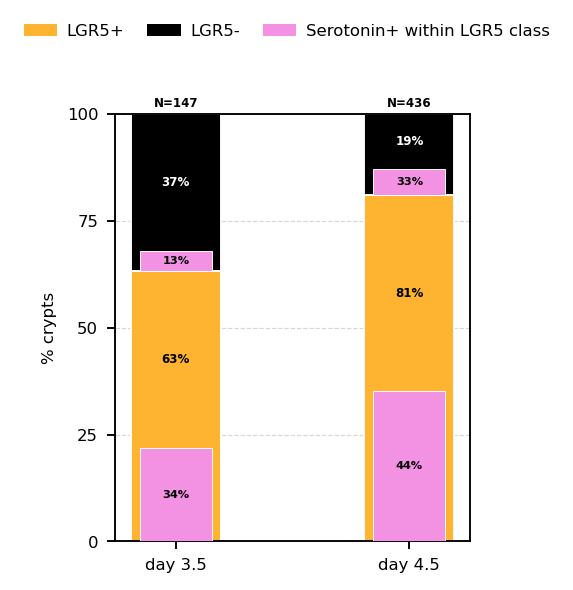

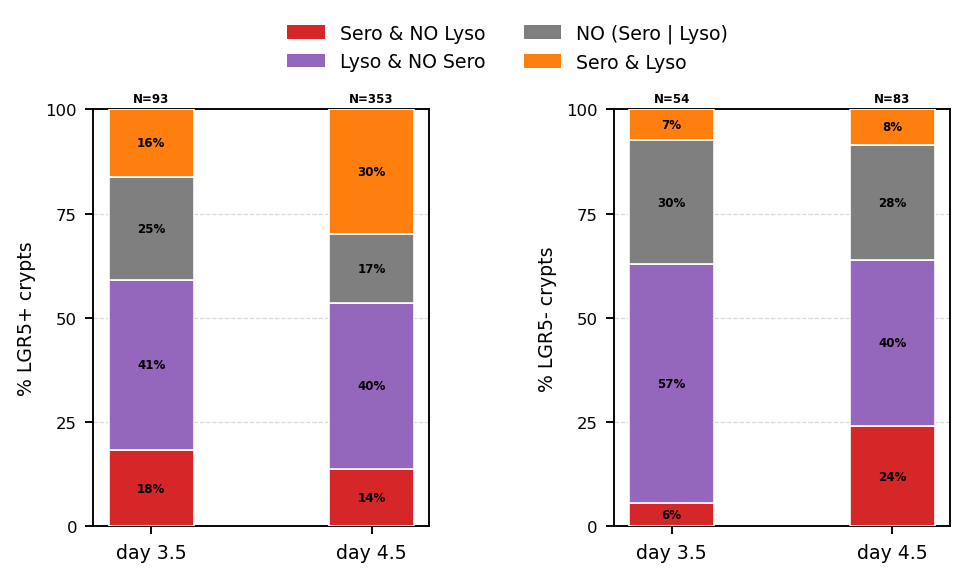

{'stack_pos': array([[0.1827957 , 0.40860215, 0.24731183, 0.16129032],
        [0.1388102 , 0.39660057, 0.16713881, 0.29745042]]),
 'stack_neg': array([[0.05555556, 0.57407407, 0.2962963 , 0.07407407],
        [0.24096386, 0.39759036, 0.27710843, 0.08433735]]),
 'Ns_pos': array([ 93, 353]),
 'Ns_neg': array([54, 83]),
 'dataset_order': ['day 3.5', 'day 4.5']}

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from colors import DEFAULT_MARKER_COLORS
DEFAULT_MARKER_COLORS = {
    "Agr2": "#359BD5",
    "Lysozyme": "#2C75D2",
    "Mucin 2": "#3EC1D9",
    "Chroma": "#D852CB",
    "Glucagon": "#983EE2",
    "Serotonin": "#F392E3",
    "LGR5": "#FFB431",
    "AldoB": "#F16C6A",
    "Cyclin D": "#808080",
    "Cyclin A": "#808080",
    "KI67": "#808080",
    "other": "#EBEBEB",
}


def build_lgr5_composition_from_inspection_table(
    inspection_df,
    sample_col="sample_label",
    lgr5_marker="LGR5",
    sero_marker="Serotonin",
):
    """
    Build a pooled table for plotting LGR5+ / LGR5- crypt composition
    and serotonin-positive fractions within each LGR5 category.
    """
    df = inspection_df.copy()

    lgr5_col = f"{lgr5_marker}_has"
    sero_col = f"{sero_marker}_has"

    if lgr5_col not in df.columns:
        raise KeyError(f"Missing required column: {lgr5_col}")
    if sero_col not in df.columns:
        raise KeyError(f"Missing required column: {sero_col}")

    rows = []

    for sample_label, g in df.groupby(sample_col, sort=False):
        valid = g[g[lgr5_col].isin([0, 1])].copy()
        N = len(valid)

        if N == 0:
            rows.append({
                "sample_label": sample_label,
                "N": 0,
                "lgr5_pos_frac": np.nan,
                "lgr5_neg_frac": np.nan,
                "sero_in_lgr5_pos_frac": np.nan,
                "sero_in_lgr5_neg_frac": np.nan,
            })
            continue

        pos_mask = valid[lgr5_col] == 1
        neg_mask = valid[lgr5_col] == 0

        n_pos = int(pos_mask.sum())
        n_neg = int(neg_mask.sum())

        lgr5_pos_frac = n_pos / N
        lgr5_neg_frac = n_neg / N

        sero_in_lgr5_pos_frac = (
            (valid.loc[pos_mask, sero_col] == 1).mean() if n_pos > 0 else np.nan
        )
        sero_in_lgr5_neg_frac = (
            (valid.loc[neg_mask, sero_col] == 1).mean() if n_neg > 0 else np.nan
        )

        rows.append({
            "sample_label": sample_label,
            "N": N,
            "lgr5_pos_frac": lgr5_pos_frac,
            "lgr5_neg_frac": lgr5_neg_frac,
            "sero_in_lgr5_pos_frac": sero_in_lgr5_pos_frac,
            "sero_in_lgr5_neg_frac": sero_in_lgr5_neg_frac,
        })

    return pd.DataFrame(rows)


def plot_lgr5_composition_from_inspection_table(
    inspection_df,
    dataset_order=None,
    sample_col="sample_label",
    lgr5_marker="LGR5",
    sero_marker="Serotonin",
    figsize=None,
    dpi=170,
    main_text_threshold=7.0,
    sero_inside_height_threshold=3.0,
):
    """
    Plot pooled LGR5+ / LGR5- crypt composition directly from inspection_df.

    Outer stacked bars:
      - LGR5+
      - LGR5-

    Inside each segment:
      - a serotonin sub-bar at 90% of full bar width
      - serotonin % always written
      - main LGR5 % placed in the remaining non-serotonin space
    """
    plot_df = build_lgr5_composition_from_inspection_table(
        inspection_df=inspection_df,
        sample_col=sample_col,
        lgr5_marker=lgr5_marker,
        sero_marker=sero_marker,
    )

    if dataset_order is None:
        dataset_order = list(pd.unique(inspection_df[sample_col]))

    pooled = plot_df.set_index("sample_label").reindex(dataset_order)

    n = len(dataset_order)
    x = np.arange(n, dtype=float) * 0.78
    w = 0.30
    sero_w = 0.80 * w

    if figsize is None:
        base_w = 1.2
        per_bar_w = 0.75
        fig_w = base_w + per_bar_w * n
        fig_h = 4.2 * 0.82
        figsize = (fig_w, fig_h)

    lgr5_pos_color = DEFAULT_MARKER_COLORS["LGR5"]
    lgr5_neg_color = "#000000"
    sero_color = DEFAULT_MARKER_COLORS["Serotonin"]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.subplots_adjust(top=0.84)

    outer_stack = np.column_stack([
        pooled["lgr5_pos_frac"].to_numpy(dtype=float),
        pooled["lgr5_neg_frac"].to_numpy(dtype=float),
    ])

    sero_within = np.column_stack([
        pooled["sero_in_lgr5_pos_frac"].to_numpy(dtype=float),
        pooled["sero_in_lgr5_neg_frac"].to_numpy(dtype=float),
    ])

    outer_colors = [lgr5_pos_color, lgr5_neg_color]
    bottom = np.zeros(n, dtype=float)

    for si in range(2):
        seg_vals = 100.0 * outer_stack[:, si]
        sero_frac = sero_within[:, si]
        sero_vals = seg_vals * sero_frac

        # Parent LGR5 segment
        bars = ax.bar(
            x,
            seg_vals,
            width=w,
            bottom=bottom,
            color=outer_colors[si],
            edgecolor="white",
            linewidth=0.8,
            zorder=2,
        )

        # Serotonin sub-bar, visually nested inside parent
        sero_bars = ax.bar(
            x,
            np.nan_to_num(sero_vals, nan=0.0),
            width=sero_w,
            bottom=bottom,
            color=sero_color,
            edgecolor="white",
            linewidth=0.4,
            zorder=3,
        )

        for rect, seg_v, sero_rect, sero_v_abs, sero_v_rel, btm in zip(
            bars, seg_vals, sero_bars, sero_vals, sero_frac, bottom
        ):
            if not np.isfinite(seg_v) or seg_v <= 0:
                continue

            xc = rect.get_x() + rect.get_width() / 2
            sero_h = np.nan_to_num(sero_v_abs, nan=0.0)
            main_text_color = "black" if si == 0 else "white"

            # Always show serotonin percentage if it is defined
            if np.isfinite(sero_v_rel):
                sero_label = f"{100 * sero_v_rel:.0f}%"

                if sero_h >= sero_inside_height_threshold:
                    # write inside pink bar
                    ax.text(
                        xc,
                        btm + sero_h / 2,
                        sero_label,
                        ha="center",
                        va="center",
                        fontsize=4.8,
                        fontweight="bold",
                        color="black",
                        zorder=4,
                        clip_on=True,
                    )
                else:
                    # very short bar: place just above pink sub-bar
                    y_text = min(btm + sero_h + 1.2, btm + seg_v - 0.8)
                    ax.text(
                        xc,
                        y_text,
                        sero_label,
                        ha="center",
                        va="bottom",
                        fontsize=4.8,
                        fontweight="bold",
                        color="black",
                        zorder=4,
                        clip_on=True,
                    )

            # Main LGR5 percentage in remaining non-serotonin region
            non_sero_v = seg_v - sero_h

            if non_sero_v >= main_text_threshold:
                y_main = btm + sero_h + non_sero_v / 2
                ax.text(
                    xc,
                    y_main,
                    f"{seg_v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=5,
                    fontweight="bold",
                    color=main_text_color,
                    zorder=4,
                    clip_on=True,
                )
            elif seg_v >= main_text_threshold:
                # fallback near top of segment
                y_main = btm + seg_v - min(1.4, 0.15 * seg_v)
                ax.text(
                    xc,
                    y_main,
                    f"{seg_v:.0f}%",
                    ha="center",
                    va="top",
                    fontsize=5,
                    fontweight="bold",
                    color=main_text_color,
                    zorder=4,
                    clip_on=True,
                )

        bottom += np.nan_to_num(seg_vals, nan=0.0)

    # N labels above bars
    trans = ax.get_xaxis_transform()
    Ns = pooled["N"].fillna(0).to_numpy(dtype=int)
    for j in range(n):
        ax.text(
            x[j],
            1.01,
            f"N={Ns[j]}",
            transform=trans,
            ha="center",
            va="bottom",
            fontsize=5,
            fontweight="bold",
            clip_on=False,
        )

    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, fontsize=7)
    ax.set_ylabel("% crypts", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=lgr5_pos_color, edgecolor="none"),
        plt.Rectangle((0, 0), 1, 1, facecolor=lgr5_neg_color, edgecolor="none"),
        plt.Rectangle((0, 0), 1, 1, facecolor=sero_color, edgecolor="none"),
    ]
    labels = ["LGR5+", "LGR5-", "Serotonin+ within LGR5 class"]

    fig.legend(
        handles,
        labels,
        frameon=False,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        fontsize=7,
        columnspacing=1.4,
        handletextpad=0.6,
    )

    plt.show()

    return plot_df


def plot_coexpression_composition_from_inspection_table(
    inspection_df,
    dataset_order=None,
    sample_col="sample_label",
    coexpression_col="coexpression_cat",
    figsize=None,
    dpi=170,
    percent_text_threshold=1.0,
    cat_colors=None,
    labels_cond=None,
):
    """
    Plot observed coexpression composition directly from inspection_df.

    Produces two stacked-bar panels:
      - left:  LGR5+ crypts
      - right: LGR5- crypts

    Within each panel, bars are stacked over the 4 coexpression classes:
      0: Sero & NO Lyso
      1: Lyso & NO Sero
      2: NO (Sero | Lyso)
      3: Sero & Lyso

    Assumes coexpression_cat encoding:
      LGR5+ : 0,1,2,3
      LGR5- : 4,5,6,7
    """
    df = inspection_df.copy()

    if coexpression_col not in df.columns:
        raise KeyError(f"Missing required column: {coexpression_col}")

    df = df[df[coexpression_col].notna()].copy()
    if len(df) == 0:
        raise ValueError("No non-null coexpression_cat values found.")

    df[coexpression_col] = df[coexpression_col].astype(int)

    if dataset_order is None:
        dataset_order = list(pd.unique(df[sample_col]))

    if labels_cond is None:
        labels_cond = [
            "Sero & NO Lyso",
            "Lyso & NO Sero",
            "NO (Sero | Lyso)",
            "Sero & Lyso",
        ]

    if cat_colors is None:
        cat_colors = ["#d62728", "#9467bd", "#7f7f7f", "#ff7f0e"]

    n = len(dataset_order)

    # fixed bar width in data coordinates
    x = np.arange(n, dtype=float) * 0.78
    w = 0.30

    # figure width scales with number of datasets/timepoints
    if figsize is None:
        base_w = 5.0      # base width for two-panel frame
        per_bar_w = 0.75  # horizontal room per dataset
        fig_w = base_w + per_bar_w * n
        fig_h = 4.2 * 0.80
        figsize = (fig_w, fig_h)

    # -------------------------------------------------
    # build per-sample observed stacks
    # -------------------------------------------------
    stack_pos = []
    stack_neg = []
    Ns_pos = []
    Ns_neg = []

    for label in dataset_order:
        sub = df[df[sample_col] == label]
        cats = sub[coexpression_col].to_numpy(dtype=int)

        # LGR5+
        counts_pos = np.array([(cats == i).sum() for i in [0, 1, 2, 3]], dtype=float)
        n_pos = int(counts_pos.sum())
        frac_pos = counts_pos / n_pos if n_pos > 0 else np.full(4, np.nan)

        # LGR5-
        counts_neg = np.array([(cats == i).sum() for i in [4, 5, 6, 7]], dtype=float)
        n_neg = int(counts_neg.sum())
        frac_neg = counts_neg / n_neg if n_neg > 0 else np.full(4, np.nan)

        stack_pos.append(frac_pos)
        stack_neg.append(frac_neg)
        Ns_pos.append(n_pos)
        Ns_neg.append(n_neg)

    stack_pos = np.vstack(stack_pos)   # (Ndatasets, 4)
    stack_neg = np.vstack(stack_neg)   # (Ndatasets, 4)
    Ns_pos = np.asarray(Ns_pos, dtype=int)
    Ns_neg = np.asarray(Ns_neg, dtype=int)

    # -------------------------------------------------
    # plotting
    # -------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    fig.subplots_adjust(wspace=0.55, top=0.84)

    def stacked_single(ax, obs_2x4, Ns, ylabel):
        bottom = np.zeros(n, dtype=float)

        for ci in range(4):
            vals = 100.0 * obs_2x4[:, ci]

            bars = ax.bar(
                x,
                vals,
                width=w,
                bottom=bottom,
                color=cat_colors[ci],
                edgecolor="white",
                linewidth=0.7,
                zorder=3,
            )

            for rect, v, btm in zip(bars, vals, bottom):
                if not np.isfinite(v) or v < percent_text_threshold:
                    continue
                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    btm + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=5,
                    fontweight="bold",
                    clip_on=True,
                    zorder=4,
                )

            bottom = bottom + np.nan_to_num(vals, nan=0.0)

        # N labels above bars
        trans = ax.get_xaxis_transform()
        for j, n_here in enumerate(Ns):
            ax.text(
                x[j], 1.01, f"N={int(n_here)}",
                transform=trans,
                ha="center",
                va="bottom",
                fontsize=5,
                fontweight="bold",
                clip_on=False,
            )

        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels(dataset_order, fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(axis="y", labelsize=7)

    stacked_single(axes[0], stack_pos, Ns_pos, "% LGR5+ crypts")
    stacked_single(axes[1], stack_neg, Ns_neg, "% LGR5- crypts")

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=cat_colors[i]) for i in range(4)]
    fig.legend(
        handles,
        labels_cond,
        frameon=False,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        fontsize=8,
    )

    plt.show()

    return {
        "stack_pos": stack_pos,
        "stack_neg": stack_neg,
        "Ns_pos": Ns_pos,
        "Ns_neg": Ns_neg,
        "dataset_order": dataset_order,
    }

plot_df = plot_lgr5_composition_from_inspection_table(
    inspection_df=inspection_df,
    dataset_order=SAMPLE_ORDER,
    sample_col="sample_label",
    lgr5_marker="LGR5",
)

plot_coexpression_composition_from_inspection_table(
    inspection_df=inspection_df,
    dataset_order=SAMPLE_ORDER,
    sample_col="sample_label",
    coexpression_col="coexpression_cat",
)


## Morphology Distributions

Saved crypt shape descriptors are compared across timepoint groups and coexpression classes.


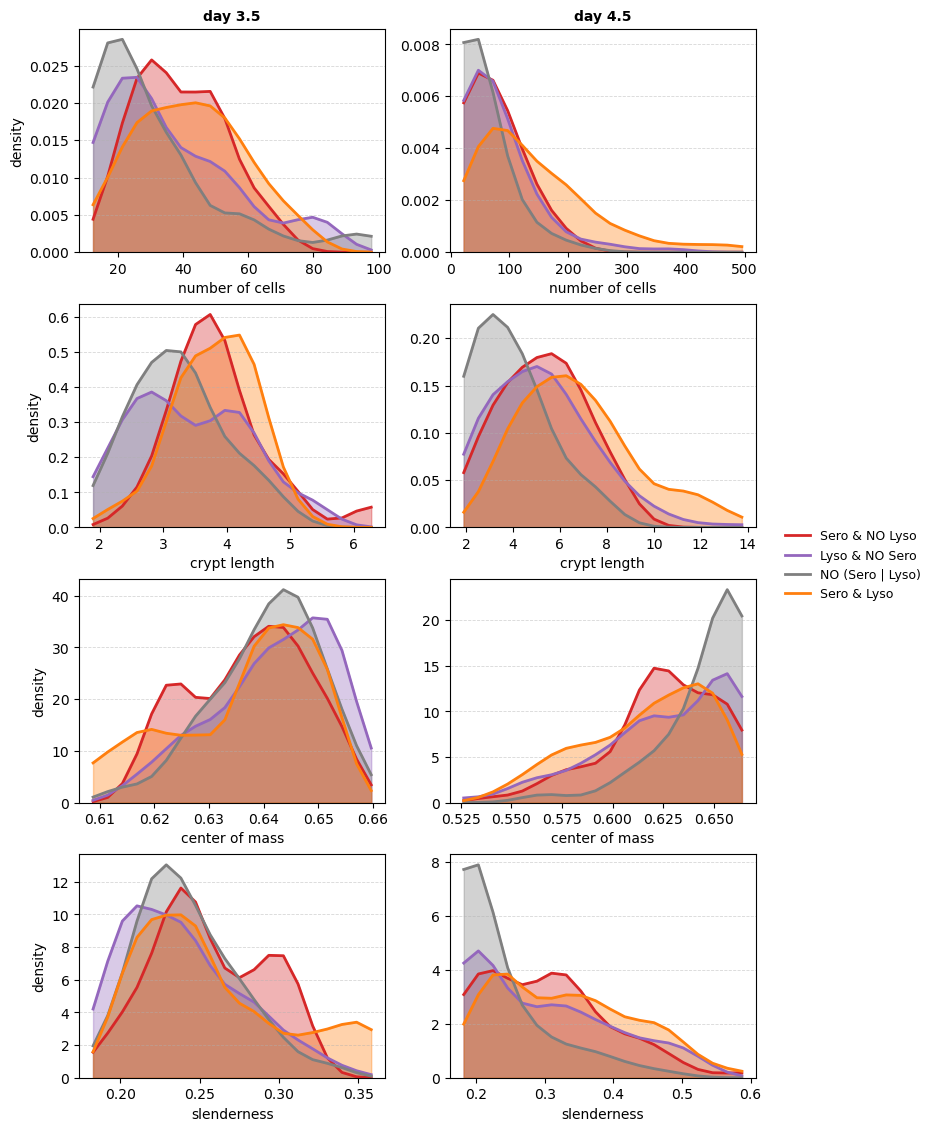

In [9]:
def add_sero_lyso_group_from_coexpression(
    inspection_df,
    coexpression_col="coexpression_cat",
    out_col="sero_lyso_group",
):
    """
    Add a 4-way grouping column inferred from coexpression_cat, pooling over LGR5 sign.

    Mapping:
      0,4 -> "Sero & NO Lyso"
      1,5 -> "Lyso & NO Sero"
      2,6 -> "NO (Sero | Lyso)"
      3,7 -> "Sero & Lyso"
    """
    df = inspection_df.copy()

    mapping = {
        0: "Sero & NO Lyso",
        1: "Lyso & NO Sero",
        2: "NO (Sero | Lyso)",
        3: "Sero & Lyso",
        4: "Sero & NO Lyso",
        5: "Lyso & NO Sero",
        6: "NO (Sero | Lyso)",
        7: "Sero & Lyso",
    }

    def _map_cat(cat):
        if pd.isna(cat):
            return np.nan
        cat = int(cat)
        return mapping.get(cat, np.nan)

    df[out_col] = df[coexpression_col].map(_map_cat)
    return df


def gaussian_smooth_1d(y, sigma_bins=1.5):
    """
    Smooth a 1D array with a Gaussian kernel defined in units of bins.
    """
    y = np.asarray(y, dtype=float)

    if sigma_bins is None or sigma_bins <= 0:
        return y.copy()

    radius = int(np.ceil(4 * sigma_bins))
    x = np.arange(-radius, radius + 1, dtype=float)
    k = np.exp(-0.5 * (x / sigma_bins) ** 2)
    k /= k.sum()

    return np.convolve(y, k, mode="same")



def plot_morphology_distributions_by_timepoint(
    inspection_df,
    *,
    value_cols,
    value_labels=None,
    timepoint_col="sample_label",
    coexpression_col="coexpression_cat",
    group_col=None,
    group_order=None,
    group_colors=None,
    bins=20,
    max_values=None,
    timepoint_order=None,
    figsize_per_panel=(3.8, 2.8),
    alpha=0.35,
    density=False,
    smoothing=False,
    smoothing_sigma_bins=1.5,
    binning_mode="same_width",   # "independent", "same_width", "same_count"
    show_means=False,
    show_medians=False,
    legend=True,
    line_width=2.0,
):
    """
    Plot histograms or smoothed distributions of morphological quantities.

    Layout:
      - columns = timepoints / datasets
      - rows = morphological quantities

    Grouping:
      - by default uses 4-way Sero/Lyso groups inferred from coexpression_cat
      - or you can pass an existing group_col

    Parameters
    ----------
    value_cols : list[str]
        Morphological quantities to plot.

    value_labels : list[str] or None
        Display labels for x-axes. If None, uses value_cols.

    bins : int, array-like, dict
        Bin specification. Can be shared or per-value_col.

    max_values : dict, scalar, or None
        Optional clipping thresholds.

    density : bool
        If True, use histogram density normalization.
        If False, use fractions within each group.

    smoothing : bool
        If True, plot smoothed curves instead of raw histogram bars.

    binning_mode : str
        One of:
          - "independent": each timepoint gets its own bins
          - "same_width" : same bin width across timepoints for a given metric
          - "same_count" : same number of bins across timepoints for a given metric
    """
    df = inspection_df.copy()

    if isinstance(value_cols, str):
        value_cols = [value_cols]
    value_cols = list(value_cols)

    if value_labels is None:
        value_labels = list(value_cols)
    else:
        value_labels = list(value_labels)

    needed = [timepoint_col] + value_cols
    if group_col is not None:
        needed.append(group_col)
    else:
        needed.append(coexpression_col)

    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    if group_col is None:
        df = add_sero_lyso_group_from_coexpression(
            df,
            coexpression_col=coexpression_col,
            out_col="sero_lyso_group",
        )
        group_col = "sero_lyso_group"

    df = df[df[group_col].notna()].copy()
    if len(df) == 0:
        raise ValueError("No rows left after filtering non-null groups.")

    if timepoint_order is None:
        timepoint_order = list(pd.unique(df[timepoint_col]))

    if group_order is None:
        group_order = [
            "Sero & NO Lyso",
            "Lyso & NO Sero",
            "NO (Sero | Lyso)",
            "Sero & Lyso",
        ]
        group_order = [g for g in group_order if g in set(df[group_col].dropna())]

    if group_colors is None:
        group_colors = {
            "Sero & NO Lyso": "#d62728",
            "Lyso & NO Sero": "#9467bd",
            "NO (Sero | Lyso)": "#7f7f7f",
            "Sero & Lyso": "#ff7f0e",
        }

    if binning_mode not in {"independent", "same_width", "same_count"}:
        raise ValueError("binning_mode must be 'independent', 'same_width', or 'same_count'")

    n_rows = len(value_cols)
    n_cols = len(timepoint_order)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
        constrained_layout=True,
        sharey=False,
    )

    def _get_bins_spec(bins, value_col):
        if isinstance(bins, dict):
            return bins.get(value_col, 20)
        return bins

    def _get_tp_max(max_values, value_col, tp):
        if max_values is None:
            return None
        if np.isscalar(max_values):
            return max_values
        if isinstance(max_values, dict):
            v = max_values.get(value_col, None)
            if v is None:
                return None
            if np.isscalar(v):
                return v
            if isinstance(v, dict):
                return v.get(tp, None)
        return None

    def _clip_vals(vals, vmax):
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vmax is not None:
            vals = vals.copy()
            vals[vals >= vmax] = vmax
        return vals

    def _make_bin_edges(vals_all, bins_spec, vmax=None):
        vals_all = np.asarray(vals_all, dtype=float)
        vals_all = vals_all[np.isfinite(vals_all)]

        if vals_all.size == 0:
            return None

        if vmax is not None:
            vals_for_bins = vals_all[vals_all <= vmax]
            if vals_for_bins.size == 0:
                vals_for_bins = np.array([0.0, vmax], dtype=float)

            if np.isscalar(bins_spec):
                vmin = np.nanmin(vals_for_bins)
                if not np.isfinite(vmin):
                    vmin = 0.0
                vmax_here = vmax if vmax > vmin else (vmin + 1.0)
                return np.linspace(vmin, vmax_here, int(bins_spec) + 1)

            return np.asarray(bins_spec, dtype=float)

        if np.isscalar(bins_spec):
            return np.histogram_bin_edges(vals_all, bins=int(bins_spec))
        return np.asarray(bins_spec, dtype=float)

    def _infer_bin_width(edges):
        if edges is None or len(edges) < 2:
            return np.nan
        d = np.diff(edges)
        d = d[np.isfinite(d) & (d > 0)]
        if len(d) == 0:
            return np.nan
        return float(np.min(d))

    def _make_edges_with_fixed_width(vals_all, width, vmax=None):
        vals_all = np.asarray(vals_all, dtype=float)
        vals_all = vals_all[np.isfinite(vals_all)]

        if vals_all.size == 0 or not np.isfinite(width) or width <= 0:
            return None

        if vmax is not None:
            vals_use = vals_all[vals_all <= vmax]
            if vals_use.size == 0:
                vals_use = np.array([0.0, vmax], dtype=float)
            vmin = float(np.nanmin(vals_use))
            vmax_here = float(vmax)
        else:
            vmin = float(np.nanmin(vals_all))
            vmax_here = float(np.nanmax(vals_all))

        if not np.isfinite(vmin) or not np.isfinite(vmax_here):
            return None

        if vmax_here <= vmin:
            vmax_here = vmin + width

        n_bins = int(np.ceil((vmax_here - vmin) / width))
        n_bins = max(n_bins, 1)

        edges = vmin + width * np.arange(n_bins + 1, dtype=float)
        if edges[-1] < vmax_here:
            edges = np.append(edges, edges[-1] + width)
        return edges

    # Precompute per-metric shared widths/count behavior
    shared_widths = {}
    for value_col in value_cols:
        bins_spec = _get_bins_spec(bins, value_col)

        if binning_mode == "same_width":
            widths = []
            for tp in timepoint_order:
                sub = df[df[timepoint_col] == tp]
                vmax = _get_tp_max(max_values, value_col, tp)
                vals_all = sub[value_col].to_numpy(dtype=float)
                vals_all = vals_all[np.isfinite(vals_all)]
                edges = _make_bin_edges(vals_all, bins_spec, vmax=vmax)
                widths.append(_infer_bin_width(edges))

            widths = np.asarray(widths, dtype=float)
            widths = widths[np.isfinite(widths) & (widths > 0)]
            shared_widths[value_col] = float(np.min(widths)) if len(widths) > 0 else None

        elif binning_mode == "same_count":
            shared_widths[value_col] = None  # not used, but keeps dict complete

    for i, (value_col, value_label) in enumerate(zip(value_cols, value_labels)):
        bins_spec = _get_bins_spec(bins, value_col)

        for j, tp in enumerate(timepoint_order):
            ax = axes[i, j]
            sub = df[df[timepoint_col] == tp].copy()

            vmax = _get_tp_max(max_values, value_col, tp)
            vals_all = sub[value_col].to_numpy(dtype=float)
            vals_all = vals_all[np.isfinite(vals_all)]

            if binning_mode == "same_width" and shared_widths.get(value_col) is not None:
                bin_edges = _make_edges_with_fixed_width(
                    vals_all,
                    width=shared_widths[value_col],
                    vmax=vmax,
                )
            else:
                # both "independent" and "same_count" come through here
                # since same_count means same bins_spec integer count
                bin_edges = _make_bin_edges(vals_all, bins_spec, vmax=vmax)

            if bin_edges is None:
                ax.axis("off")
                continue

            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            bin_widths = np.diff(bin_edges)

            for grp in group_order:
                vals = sub.loc[sub[group_col] == grp, value_col].to_numpy(dtype=float)
                vals = _clip_vals(vals, vmax)

                if vals.size == 0:
                    continue

                color = group_colors.get(grp, None)

                if smoothing:
                    hist, _ = np.histogram(vals, bins=bin_edges)

                    if density:
                        y = hist / (hist.sum() * bin_widths)
                    else:
                        y = hist / hist.sum()

                    y_s = gaussian_smooth_1d(y, sigma_bins=smoothing_sigma_bins)

                    ax.plot(
                        bin_centers,
                        y_s,
                        color=color,
                        linewidth=line_width,
                        label=grp,
                    )
                    ax.fill_between(
                        bin_centers,
                        0,
                        y_s,
                        color=color,
                        alpha=alpha,
                    )
                else:
                    hist_kwargs = dict(
                        bins=bin_edges,
                        alpha=alpha,
                        label=grp,
                        color=color,
                    )

                    if density:
                        hist_kwargs["density"] = True
                    else:
                        hist_kwargs["weights"] = np.full(vals.shape, 1.0 / len(vals), dtype=float)

                    ax.hist(vals, **hist_kwargs)

                if show_means:
                    ax.axvline(
                        np.mean(vals),
                        linestyle="--",
                        linewidth=1.2,
                        color=color if color is not None else "k",
                    )

                if show_medians:
                    ax.axvline(
                        np.median(vals),
                        linestyle=":",
                        linewidth=1.2,
                        color=color if color is not None else "k",
                    )

            if vmax is not None:
                ax.axvline(vmax, linestyle=":", linewidth=1.0, color="black")

            if i == 0:
                ax.set_title(f"{tp}", fontweight="bold", fontsize=10)

            ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
            ax.set_ylim(bottom=0)

            # show x-label on every subplot
            ax.set_xlabel(value_label)

            if j == 0:
                ax.set_ylabel("density" if density else "fraction of crypts")

    if legend:
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if len(handles) > 0:
            # deduplicate labels
            seen = set()
            uniq_handles = []
            uniq_labels = []
            for h, l in zip(handles, labels):
                if l not in seen:
                    uniq_handles.append(h)
                    uniq_labels.append(l)
                    seen.add(l)

            fig.legend(
                uniq_handles,
                uniq_labels,
                frameon=False,
                ncol=1,
                loc="center left",
                bbox_to_anchor=(1.01, 0.5),
                fontsize=9,
            )

    plt.show()

plot_morphology_distributions_by_timepoint(
    inspection_df=inspection_df,
    value_cols=["num_cells", "crypt_length", "crypt_fullness", "crypt_slenderness"],
    value_labels=["number of cells", "crypt length", "center of mass", "slenderness"],
    timepoint_col="sample_label",
    timepoint_order=SAMPLE_ORDER,
    bins=20,
    density=True,
    smoothing=True,
    smoothing_sigma_bins=1.5,
    binning_mode="independent",
)


### Crypt Constriction Distribution

The saved segmentation variable `crypt_constrictions` is stored in `inspection_df` as `constriction`. This quick plot compares its distribution across pooled timepoint groups.


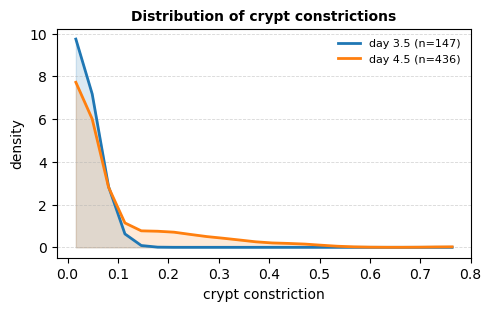

In [ ]:
def plot_crypt_constriction_distribution(
    inspection_df,
    *,
    value_col="constriction",
    timepoint_col="sample_label",
    timepoint_order=SAMPLE_ORDER,
    bins=24,
    density=True,
    smoothing=True,
    smoothing_sigma_bins=1.25,
):
    if value_col not in inspection_df.columns:
        raise KeyError(f"Missing column {value_col!r}; expected crypt_constrictions to be loaded as this column.")

    df = inspection_df[[timepoint_col, value_col]].dropna().copy()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[value_col])
    if df.empty:
        raise ValueError("No finite crypt constriction values found.")

    vals_all = df[value_col].to_numpy(dtype=float)
    bin_edges = np.histogram_bin_edges(vals_all, bins=bins)
    bin_widths = np.diff(bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    colors = dict(zip(timepoint_order, plt.get_cmap("tab10").colors[:len(timepoint_order)]))
    fig, ax = plt.subplots(figsize=(4.8, 3.0), constrained_layout=True)

    for sample_label in timepoint_order:
        vals = df.loc[df[timepoint_col] == sample_label, value_col].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        hist, _ = np.histogram(vals, bins=bin_edges)
        if hist.sum() == 0:
            continue

        if density:
            y = hist / (hist.sum() * bin_widths)
        else:
            y = hist / hist.sum()

        color = colors.get(sample_label, None)
        ax.plot(bin_centers, y, color=color, linewidth=2.0, label=f"{sample_label} (n={vals.size})")
        ax.fill_between(bin_centers, 0, y, color=color, alpha=0.16)

    ax.set_xlabel("crypt constriction")
    ax.set_ylabel("density" if density else "fraction of crypts")
    ax.set_title("Distribution of crypt constrictions", fontsize=10, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.legend(frameon=False, fontsize=8)
    plt.show()
    return fig, ax


fig, ax = plot_crypt_constriction_distribution(inspection_df)


## Split-Out Distance Profiles

The marker-fraction figures along crypt axes were moved to `plot_marker_fractions_along_crypt_axes.ipynb` to keep composition summaries and distance-profile figures separate.
